# Simple Phase Grating

This script demonstrates how to create a simple diffraction grating using the `PhaseInteractionModel` and `GratingPhase` in Optiland. It sets up a simple optical system with a single surface that acts as a grating and traces some rays through it to observe the diffraction.

In [1]:
from optiland import optic, phase
import optiland.backend as be

In [2]:
class SimpleGratingSystem(optic.Optic):
    """
    Defines a simple optical system with a diffraction grating.
    """
    def __init__(self):
        super().__init__()
        # Surface 0: Object plane
        self.add_surface(index=0, z=0)

        # Surface 1: Grating surface
        # 2.5 um period, 1st order
        grating = phase.GratingPhase(period=0.25, order=1)
        self.add_surface(
            index=1,
            radius=-1000,
            z=50,
            rx=be.pi/4,
            phase_model=grating,
            material="mirror",
            is_stop=True
        )

        # Surface 2: Image plane
        self.add_surface(index=2, z=50, rx=be.pi/2, y=50)

        # System aperture and field
        self.set_aperture(aperture_type="EPD", value=20)
        self.set_field_type(field_type="angle")
        self.add_field(y=0)

        # Wavelengths
        self.add_wavelength(value=0.550, is_primary=True) # Green
        self.add_wavelength(value=0.450) # Blue
        self.add_wavelength(value=0.650) # Red

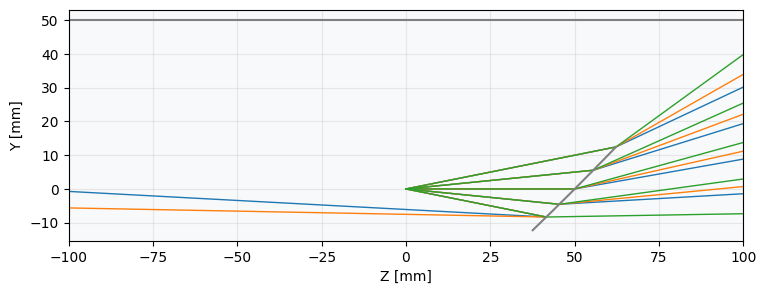

In [3]:
lens = SimpleGratingSystem()
_ = lens.draw(num_rays=5, wavelengths=[0.450, 0.550, 0.650], figsize=(10, 3), xlim=(-100, 100))